In [1]:
import sys
#sys.path.append("/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/graphnet/lib/python3.8/site-packages/")

#import cartopy
#import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import numpy as np

#sys.path.insert(0, "/user/work/ef17148/oldstuff/ef17148/.conda/envs/GCN_env/lib/python3.8/site-packages/")
'''
sys.path.insert(0,"/software/local/languages/miniforge3/envs/tensorflow/lib/python3.12/site-packages")
#sys.path.insert(0,"/user/work/ef17148/oldstuff/ef17148/.conda/envs/new_graphnet/lib/python3.12/site-packages")
sys.path.insert(0,"/user/work/yl18410/.conda/envs/new_graphnet/lib/python3.12/site-packages")
'''
print(sys.path)


import torch
import os
import pickle
import einops

#import plenoptic as po
#sys.path.insert(0, "/user/work/yl18410/GCN/graphnet/")
#sys.path.insert(0, "/user/work/yl18410/graphnet_LPDM_emulator")
sys.path.insert(0, "/user/work/yl18410/new_graphnet")
sys.path.insert(0, "/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/")
from graphnet_LPDM_emulator.model.layers.encoder import *
from graphnet_LPDM_emulator.model.layers.decoder import *
from graphnet_LPDM_emulator.model.layers.processor import *
from graphnet_LPDM_emulator.model.layers.graph_net_block import *
from graphnet_LPDM_emulator.model.data.dataloader_graphnet import *
from graphnet_LPDM_emulator.model.data.load_data import *
from graphnet_LPDM_emulator.model.loss_functions import *
#from graphnet_LPDM_emulator.model.evaluation import *

from sklearn.neural_network import MLPRegressor
import torch.optim as optim
from sklearn.metrics import mean_squared_error, r2_score
import time
from datetime import datetime
import json
import argparse

import random
from sklearn.model_selection import train_test_split

%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)



['/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator', '/user/work/yl18410/graphnet_bp_220324/lib/python39.zip', '/user/work/yl18410/graphnet_bp_220324/lib/python3.9', '/user/work/yl18410/graphnet_bp_220324/lib/python3.9/lib-dynload', '', '/user/home/yl18410/.local/lib/python3.9/site-packages', '/user/work/yl18410/graphnet_bp_220324/lib/python3.9/site-packages']


/user/work/yl18410/graphnet_bp_220324/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def getint_updated(filename):
    basename = os.path.basename(filename)
    num_part = basename.split('_')[-1].split('.')[0]
    return int(num_part) if num_part.isdigit() else -1  # give non-numeric ones a low sort order

def get_checkpoint_to_load_updated(model_name, directory, prefer_best=True):
    print(f"loading checkpoint for {model_name}")
    
    model_dir = os.path.join(directory, model_name)
    best_path = os.path.join(model_dir, f"{model_name}_best.pt")
    
    if prefer_best and os.path.exists(best_path):
        print(f"Found best checkpoint: {best_path}")
        return best_path

    # Fallback: load the latest numbered checkpoint
    pattern = os.path.join(model_dir, f"{model_name}_*.pt")
    files = sorted(
        [f for f in glob.glob(pattern) if getint(f) != -1],
        key=getint
    )
    
    assert len(files) > 0, f"No numeric checkpoint files found for model name {model_name}"
    checkpoint_to_load = files[-1]
    print(f"Loading latest checkpoint: {checkpoint_to_load}")
    
    return checkpoint_to_load

def get_checkpoint_to_load(model_name,directory):
    print(f"loading last checkpoint for {model_name}")
    #directory="/user/work/ef17148/GCN/graphnet/graph_weather/trained_satellite_models_fixedmet/"
    files = sorted(glob.glob(glob.escape(f"{directory}{model_name}/{model_name}_")+"*.pt"), key=getint)
    assert len(files)>0, f"no files found for model name {model_name}"
    checkpoint_to_load = files[-1] 
        
    return checkpoint_to_load 

## Boundary conditions

In [3]:

folder_name = 'boundary_condition'
'''
model_name ='trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-100-epochs-150_baselines_True_lr-5e-05_seed-31_date-Mar-02-2025'
model_name = 'num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-22-2025'
'''
model_name = 'num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-180_resolution-2_epochs-150_lr-5e-05_seed-31_date-May-18-2025'

#folder_name = 'mol_fraction_footprint'
'''
model_name ='trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-04-2025'
'''


#model_name = 'num_classes-4-lossweight-0.0-baselines-True-trainyear-2014_trainfreq-3_size-100-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-21-2025'


'''
model_name = 'num_classes-5-lossweight-0.0-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Apr-08-2025'


# Use this one below if not using the current one
model_name = 'num_classes-4-lossweight-0.0-baselines-True-trainyear-2014_trainfreq-3_size-100-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Apr-02-2025'
'''

inference_path=f"/user/work/yl18410/graphnet_LPDM_emulator/graph_weather/trained_satellite_models_fixedmet/{folder_name}/"
#model_name='trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-50-epochs-150_baselines_False_lr-5e-05_seed-31_date-Jan-18-2025'
#model_name = 'trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-50-epochs-150_baselines_True_lr-5e-05_seed-31_date-Jan-17-2025'
#model_name = 'trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-100-epochs-150_baselines_True_lr-5e-05_seed-31_date-Feb-11-2025'


data_dir = inference_path
data_save_name = f"{inference_path}{model_name}/{model_name}_final_epoch_data.pkl"
#'trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-50-epochs-150_baselines_False_lr-5e-05_seed-31_date-Jan-18-2025_final_epoch_data.pkl'

#data_dict = {'test_dataset_predictions':test_out,'test_dataset_truths':test_outputs}


with open(f'{data_save_name}', 'rb') as f:
    loaded_filtered_data_dict = pickle.load(f)


In [4]:
checkpoint_to_load = get_checkpoint_to_load(model_name,inference_path)

loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-180_resolution-2_epochs-150_lr-5e-05_seed-31_date-May-18-2025


In [5]:
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))

In [10]:
output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']

In [12]:
loaded_filtered_data_dict['test_dataset_predictions'].shape

(710, 4)

In [ ]:
truths = loaded_filtered_data_dict['test_dataset_truths']
#normalized_truths = (truths -output_mean)/output_std
predictions = loaded_filtered_data_dict['test_dataset_predictions']


(710, 4)

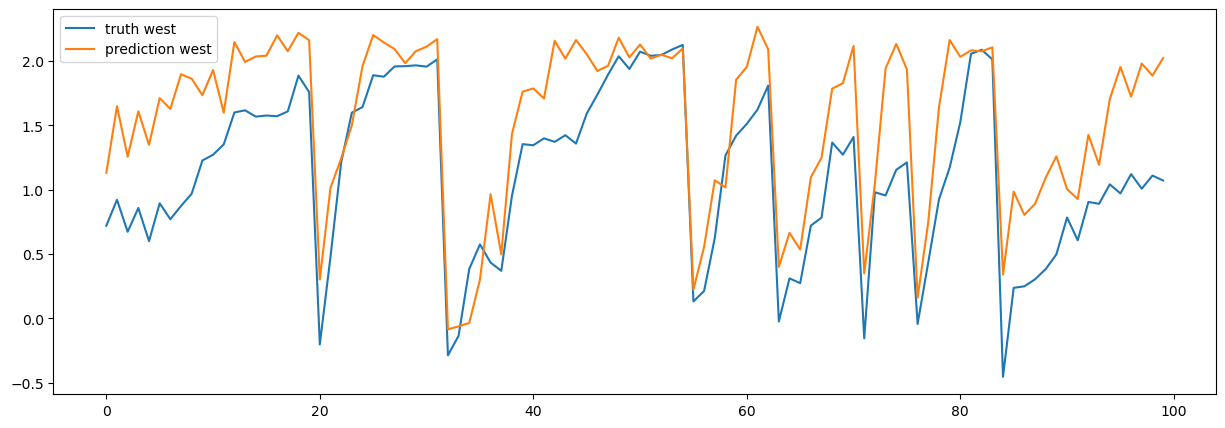

In [15]:
n=2000
w=100
fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(truths[n:n+w,3],label = 'truth west')
plt.plot(predictions[n:n+w,3],label = 'prediction west')
plt.legend()
plt.show() 

# Denormalized data

In [20]:
truths = loaded_filtered_data_dict['test_dataset_truths']
#normalized_truths = (truths -output_mean)/output_std
predictions = loaded_filtered_data_dict['test_dataset_predictions']
output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']
denormalized_truths = (truths*output_std) +output_mean
denormalized_predictions = (predictions*output_std) +output_mean


# Denromalized data with best models

loading checkpoint for num_classes-4_baselines-False_coarsening-1_normalization-all_trainyear-2015_trainfreq-3_epochs-100_lr-5e-07_seed-31_date-Jun-24-2025
Found best checkpoint: /user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/boundary_condition/num_classes-4_baselines-False_coarsening-1_normalization-all_trainyear-2015_trainfreq-3_epochs-100_lr-5e-07_seed-31_date-Jun-24-2025/num_classes-4_baselines-False_coarsening-1_normalization-all_trainyear-2015_trainfreq-3_epochs-100_lr-5e-07_seed-31_date-Jun-24-2025_best.pt
0.0


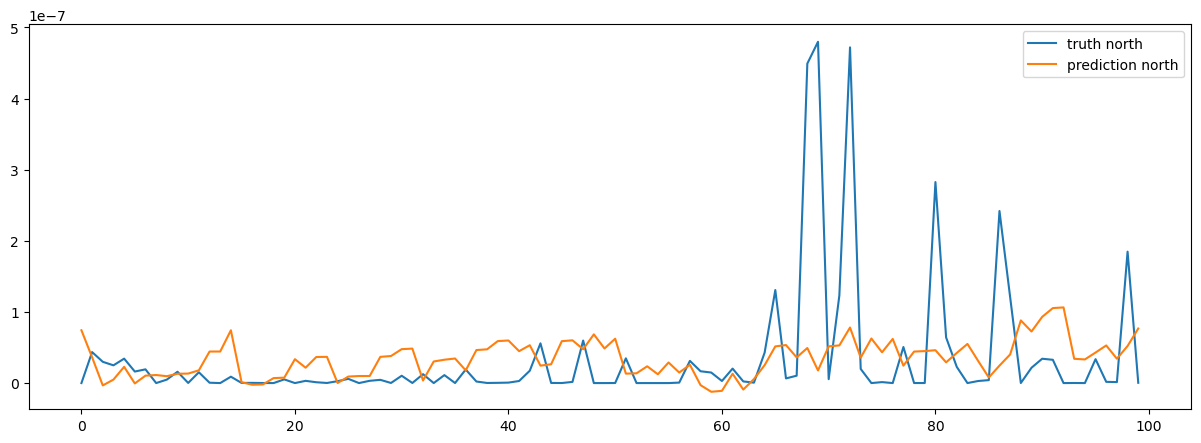

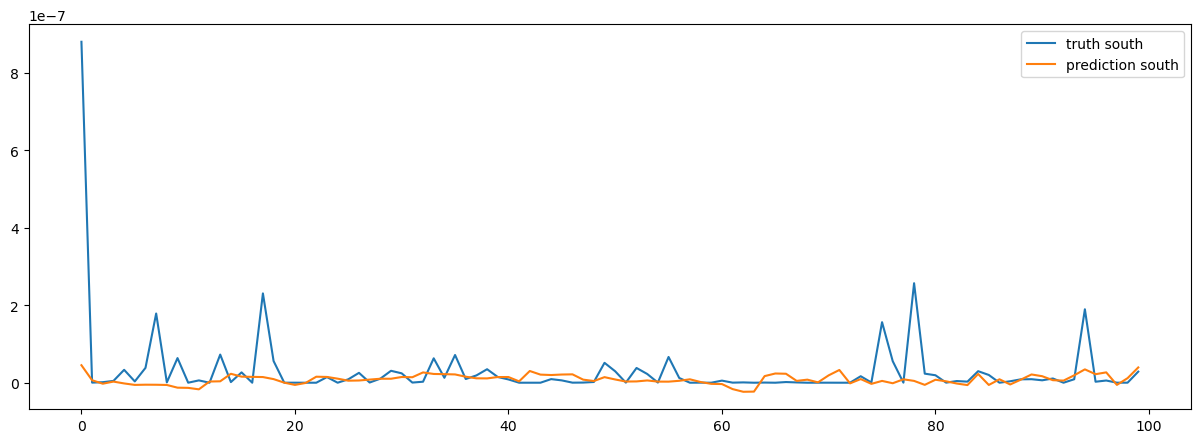

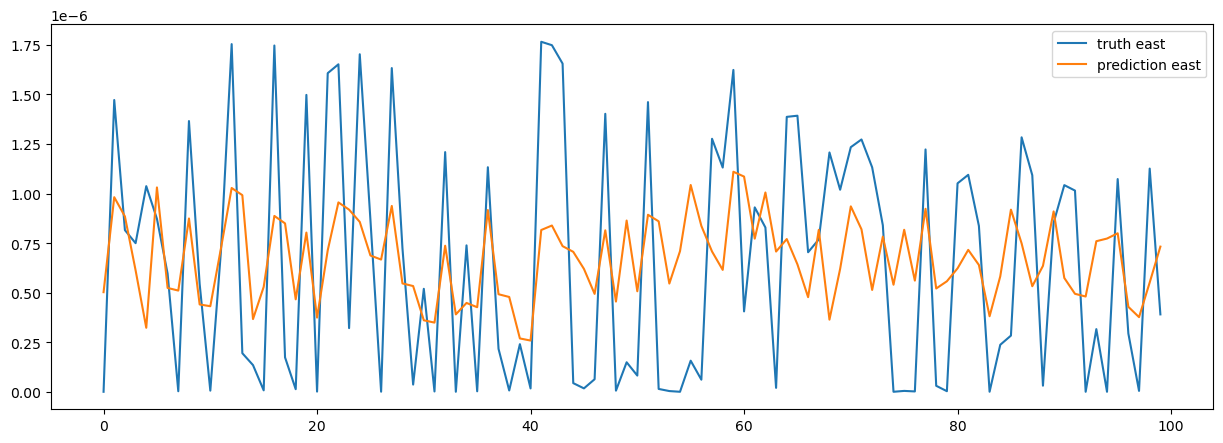

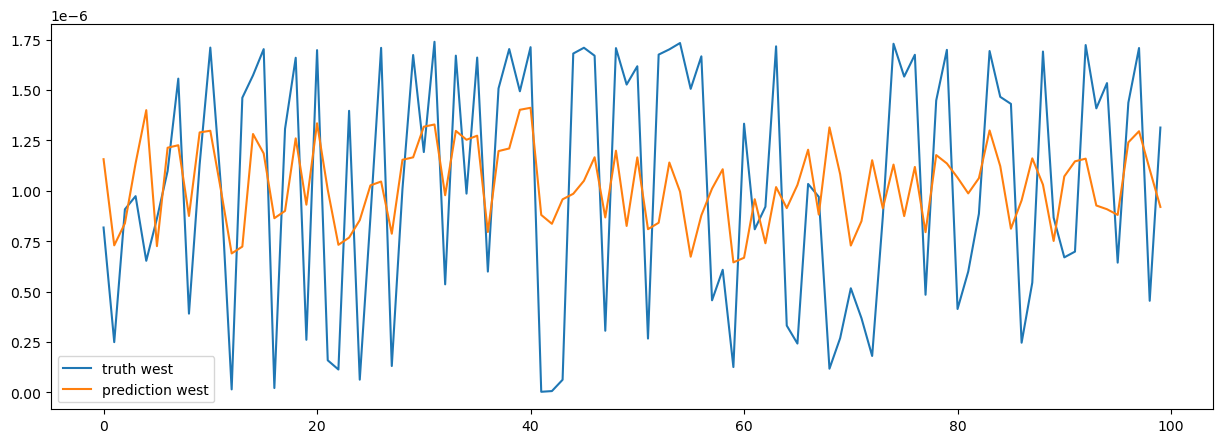

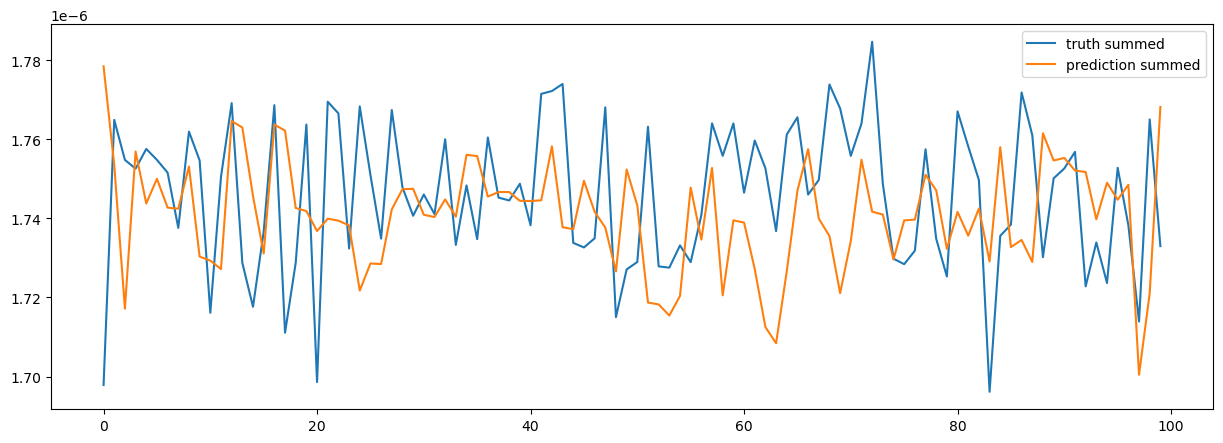

1.7731064298271676e-08


In [ ]:

folder_name = 'boundary_condition'

#model_name = 'num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-180_resolution-2_epochs-100_lr-5e-07_seed-31_date-May-22-2025'
model_name = 'num_classes-4_baselines-False_coarsening-1_normalization-all_trainyear-2015_trainfreq-3_epochs-100_lr-5e-07_seed-31_date-Jun-24-2025'
#model_name = 'num_classes-4_baselines-False_coarsening-2_normalization-all_trainyear-2015_trainfreq-5_epochs-100_lr-5e-07_seed-42_date-Jul-06-2025'
inference_path=f"/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/{folder_name}/"

data_save_name = f"{inference_path}{model_name}/{model_name}_best_predictions.npz"

loaded_filtered_data_dict = np.load(data_save_name)
predictions = loaded_filtered_data_dict['predictions']
truths = loaded_filtered_data_dict['truths']


checkpoint_to_load = get_checkpoint_to_load_updated(model_name,inference_path, prefer_best=True)
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))

output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']
denormalized_truths = (truths*output_std) +output_mean
denormalized_predictions = (predictions*output_std) +output_mean
print(denormalized_truths.min())
n=200
w=100

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,0],label = 'truth north')
plt.plot(denormalized_predictions[n:n+w,0],label = 'prediction north')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,1],label = 'truth south')
plt.plot(denormalized_predictions[n:n+w,1],label = 'prediction south')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 


fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,2],label = 'truth east')
plt.plot(denormalized_predictions[n:n+w,2],label = 'prediction east')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,3],label = 'truth west')
plt.plot(denormalized_predictions[n:n+w,3],label = 'prediction west')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 


denormalized_truths_summed = np.sum(denormalized_truths,axis=1)
denormalized_predictions_summed = np.sum(denormalized_predictions,axis=1) #+1e-8# Nawid- Small bias to improve prediction

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths_summed[n:n+w],label = 'truth summed')
plt.plot(denormalized_predictions_summed[n:n+w],label = 'prediction summed')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show()


mae = np.mean(np.abs(denormalized_truths_summed - denormalized_predictions_summed ))
print(mae)

loading checkpoint for num_classes-4_baselines-False_coarsening-4_normalization-all_trainyear-2015_trainfreq-5_epochs-100_lr-5e-07_seed-31_date-Jul-03-2025
Found best checkpoint: /user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/boundary_condition/num_classes-4_baselines-False_coarsening-4_normalization-all_trainyear-2015_trainfreq-5_epochs-100_lr-5e-07_seed-31_date-Jul-03-2025/num_classes-4_baselines-False_coarsening-4_normalization-all_trainyear-2015_trainfreq-5_epochs-100_lr-5e-07_seed-31_date-Jul-03-2025_best.pt
0.0


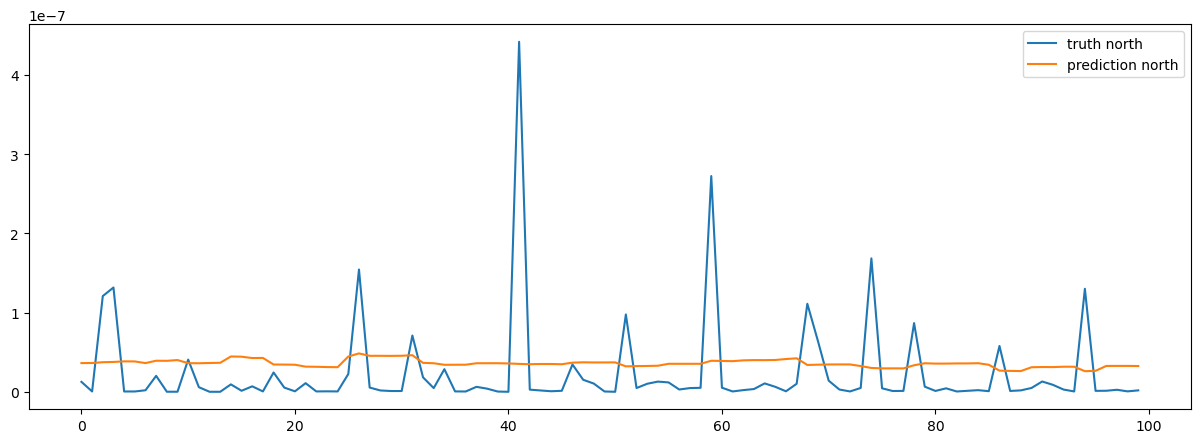

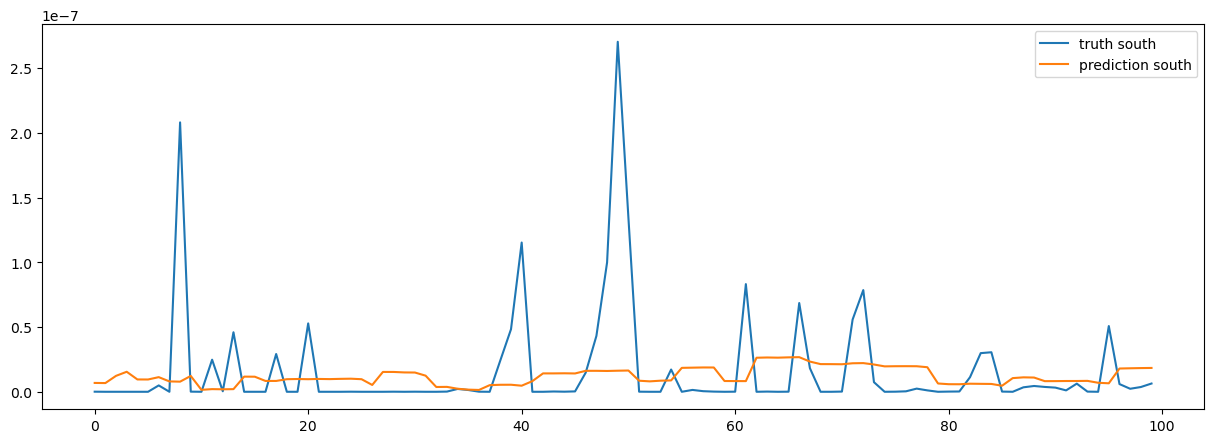

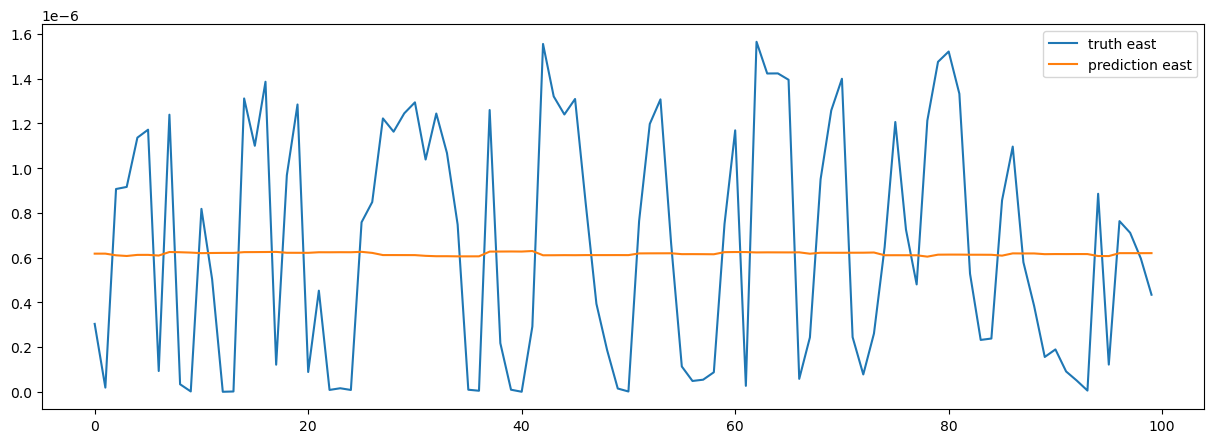

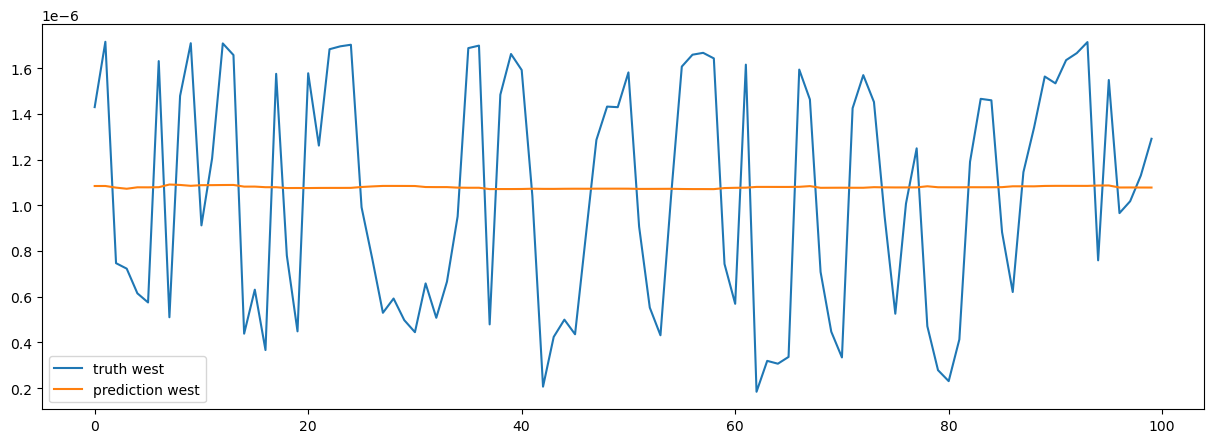

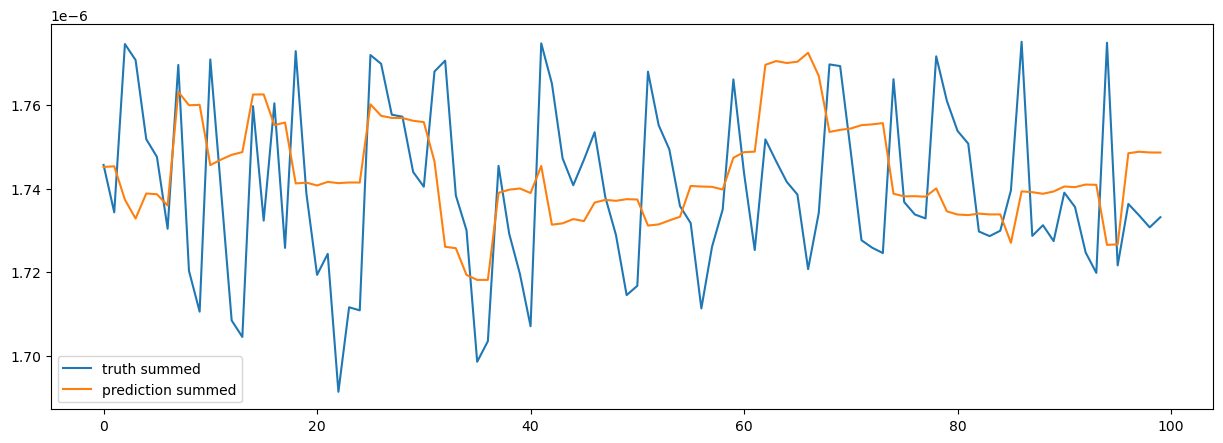

1.886280006301809e-08


In [10]:

folder_name = 'boundary_condition'

#model_name = 'num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-180_resolution-2_epochs-100_lr-5e-07_seed-31_date-May-22-2025'
#model_name = 'num_classes-4_baselines-False_coarsening-2_normalization-all_trainyear-2015_trainfreq-3_epochs-100_lr-5e-07_seed-31_date-Jun-25-2025'
model_name = 'num_classes-4_baselines-False_coarsening-4_normalization-all_trainyear-2015_trainfreq-5_epochs-100_lr-5e-07_seed-31_date-Jul-03-2025'
inference_path=f"/user/work/yl18410/new_graphnet/graphnet_LPDM_emulator/graph_weather/{folder_name}/"

data_save_name = f"{inference_path}{model_name}/{model_name}_best_predictions.npz"

loaded_filtered_data_dict = np.load(data_save_name)
predictions = loaded_filtered_data_dict['predictions']
truths = loaded_filtered_data_dict['truths']


checkpoint_to_load = get_checkpoint_to_load_updated(model_name,inference_path, prefer_best=True)
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))

output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']
denormalized_truths = (truths*output_std) +output_mean
denormalized_predictions = (predictions*output_std) +output_mean
print(denormalized_truths.min())
n=300
w=100

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,0],label = 'truth north')
plt.plot(denormalized_predictions[n:n+w,0],label = 'prediction north')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,1],label = 'truth south')
plt.plot(denormalized_predictions[n:n+w,1],label = 'prediction south')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 


fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,2],label = 'truth east')
plt.plot(denormalized_predictions[n:n+w,2],label = 'prediction east')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths[n:n+w,3],label = 'truth west')
plt.plot(denormalized_predictions[n:n+w,3],label = 'prediction west')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show() 


denormalized_truths_summed = np.sum(denormalized_truths,axis=1)
denormalized_predictions_summed = np.sum(denormalized_predictions,axis=1) #+1e-8# Nawid- Small bias to improve prediction

fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths_summed[n:n+w],label = 'truth summed')
plt.plot(denormalized_predictions_summed[n:n+w],label = 'prediction summed')
plt.legend()
#plt.ylim(0, 1e-6)
plt.show()


mae = np.mean(np.abs(denormalized_truths_summed - denormalized_predictions_summed ))
print(mae)

In [13]:
predictions = loaded_filtered_data_dict['predictions']
truths = loaded_filtered_data_dict['truths']
output_std

5.760291630091726e-07

## Calibrating the data

In [ ]:
corrected = quantile_mapping_interp(denormalized_truths_summed,denormalized_predictions_summed,denormalized_predictions_summed,n_quantiles=1000 )
mae = np.mean(np.abs(denormalized_truths_summed - denormalized_predictions_summed ))
print(mae)
mae = np.mean(np.abs(denormalized_truths_summed - corrected ))
print(mae)

for i in range(4):  
    corrected = quantile_mapping_interp(denormalized_truths[:,i],denormalized_predictions[:,i],denormalized_predictions[:,i])
    mae = np.mean(np.abs(denormalized_truths[:,i] - denormalized_predictions[:,i]))
    print(mae)
    mae = np.mean(np.abs(denormalized_truths[:,i] - corrected))
    print('corrected',mae)

1.4264644950799368e-08
1.767521911227634e-08
1.3747461566252104e-08
corrected 1.1066105951605097e-08
1.3809557813507514e-08
corrected 1.4682079768630035e-08
7.986280154262652e-08
corrected 7.777999328067128e-08
8.348365210696878e-08
corrected 8.36397333541684e-08


In [13]:
denormalized_truths.shape

(6985, 4)

### Approximation using the hemisphere

In [2]:
data = LoadSatelliteData(year="2017", region="BRAZIL", freq=3, metsize=100, size =100, topog="default", verbose=True, met_datadir="/group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_200_all_")


Loading footprint data from /group/chemistry/acrg/LPDM/fp_NAME_pre20210701/SOUTHAMERICA/*BRAZIL*SOUTHAMERICA_2017*.nc
reduced the number of datapoints by frequency 3
Cutting footprints to size
2412 footprints were at least partially filled with all_nans because they were cutting outside of the footprint file domain (this is 32.38% of samples)
footprints that are partially out of the domain in each direction: {'N': 0, 'S': 0, 'E': 2211, 'W': 201}
maximum out-of-domain index in each direction: {'N': 0, 'S': 0, 'E': 217, 'W': -6}
Loading meteorology from /group/chemistry/acrg/met_archive/UM/cut_SOUTHAMERICA_big/Met_cut_v2_200_all_2017*.nc
met levels []
met and fp_data have different timeframes! could be because either is already frequency-reduced or due to selected time indeces.
there are 20986 met timepoints, 7449 footprint timepoints, and 6985 are in common. reducing both to the common points - could go wrong but shouldnt!
passed met is bigger than the passed metsize (sizes (100, 200)).

In [4]:
def baseline_mol(desired_data,months,desired_year):
    '''
    Function used to get the value for the input and output
    '''
    total_data_points = desired_data.fp_data_full.particle_locations_n.time.shape[-1]                                                                      
    # Load the CSV file
    df = pd.read_csv('CH4_Semihemispheric_modelled_mole_fractions.csv')
    baseline_list = np.zeros((total_data_points,4))

    '''
    # Specify the year and month you're interested in
    # Filter the data for the specific year and month
    filtered_data = df[(df['Year'] == specific_year) & (df['Month'] == specific_month)]

    # Extract the 4th, 5th, 6th, and 7th columns
    selected_columns = filtered_data.iloc[:, [3, 4, 5, 6]].values

    # Display the results
    print(selected_columns)
    '''

    # Iterate through the different numbers 
    #months = ['01','02','03','04','05','06','07','08','09','10','11','12']
    #year = 2016
    datetime_array = np.array(desired_data.fp_data_full.particle_locations_n.time)

    total_data_points = desired_data.fp_data_full.particle_locations_n.time.shape[-1]
    north_list = np.zeros(total_data_points) # Creates a list of size N with None values
    south_list = np.zeros(total_data_points)
    east_list = np.zeros(total_data_points)
    west_list = np.zeros(total_data_points)

    for month in months:
        # Cams field for a particular month
        if desired_year > 2017:
            # Change made due to the naming of the data
            cams = xr.open_dataset(f"/group/chemistry/acrg/LPDM/bc/SOUTHAMERICA/ch4_SOUTHAMERICA_{desired_year}{month}_CAMS-inversion_climatology.nc")
        else:
            cams = xr.open_dataset(f"/group/chemistry/acrg/LPDM/bc/SOUTHAMERICA/ch4_SOUTHAMERICA_{desired_year}{month}_CAMS-inversion.nc")    
        # Extract year and month
        years = np.array([np.datetime64(date, 'Y').astype(int) + 1970 for date in datetime_array])
        months = np.array([np.datetime64(date, 'M').astype(int) % 12 + 1 for date in datetime_array])

        # Desired year and month
        #desired_year = 2016
        desired_month = month
        print('desired month',desired_month)

        # Find the index of the first occurrence
        indices = np.where((years == desired_year) & (months == int(desired_month)))[0]
        print(indices)
        if len(indices)>0:
            # Get the inputs
            filtered_data = df[(df['Year'] == desired_year) & (df['Month'] == int(desired_month))]
            # Extract the 4th, 5th, 6th, and 7th columns
            selected_columns = filtered_data.iloc[:, [3, 4, 5, 6]].values
            baseline_list[indices] = selected_columns/1000 # Convert from parts per trillion to parts per million



            print(indices[0])
            # Multply the first value with all the other values of the array
            print(cams.vmr_n.shape)
            # CAMS field should be stationary over the period of a month
            north_mol = np.sum(cams.vmr_n[0] * desired_data.fp_data_full.particle_locations_n[:,:,indices], axis=(0,1))
            south_mol = np.sum(cams.vmr_s[0] * desired_data.fp_data_full.particle_locations_s[:,:,indices], axis=(0,1))
            east_mol = np.sum(cams.vmr_e[0] * desired_data.fp_data_full.particle_locations_e[:,:,indices], axis=(0,1))
            west_mol = np.sum(cams.vmr_w[0] * desired_data.fp_data_full.particle_locations_w[:,:,indices], axis=(0,1))

            north_list[indices] = north_mol
            south_list[indices] = south_mol
            east_list[indices] = east_mol
            west_list[indices] = west_mol


        print(baseline_list)
        #cams = xr.open_dataset("/group/chemistry/acrg/LPDM/bc/SOUTHAMERICA/ch4_SOUTHAMERICA_201611_CAMS-inversion.nc")
        # Making the assumption that the values in the month are not different, get the first value
        # Multiple the different values
        cams
    
    return baseline_list, north_list, south_list, east_list, west_list
test_months = ['01','02','03','04','05','06','07','08','09','10','11','12']
test_year = 2017
    
baseline_list, north_list, south_list, east_list, west_list = baseline_mol(data,test_months, test_year)

# Baseline list is ordered in the same times as te array
# Make it so that each column of the baseline array is multiplied by the diffeent directions of the data

desired month 01
[  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 123 124 125
 126 127 128 129 130 131 132 133 134 135 136 137 138 139 140 141 142 143
 144 145 146 147 148 149 150 151 152 153 154 155 156 157 158 159 160 161
 162 163 164 165 166 167 168 169 170 171 172 173 174 175 176 177 178 179
 180 181 182 183 184 185 186 187 188 189 190 191 192 193 194 195 196 197
 198 199 200 201 202 203 204 205 206 207 208 209 210 211 212 213 214 215
 216 217 218 219 220 221 222 223 224 225 226 227 228 229 230 231 232 233
 234 235 236 237 238 239 240 241 2

<xarray.DataArray ()>
array(1.06877723e-07)
<xarray.DataArray ()>
array(5.72265968e-08)
<xarray.DataArray ()>
array(1.29786356e-08)
<xarray.DataArray ()>
array(1.01298988e-08)
(4815,)


'   \nfig, ax = plt.subplots(1,1,figsize=(15,5))\nplt.plot(denormalized_truths_summed[n:n+w],label = \'truth summed\')\nplt.plot(denormalized_predictions_summed[n:n+w],label = \'prediction summed\')\n# Loop to add different lines on top\n\nfor i in range(1, 4):  # Just 3 variations for demo\n    y = np.sin(x + i * 0.5)  # Example of shifting the sine wave\n    plt.plot(x, y, label=f\'Line {i}\')\n\n# Add legend and show plot\nplt.legend()\nplt.title("Overlaying Multiple Lines on Base Line")\nplt.xlabel("x")\nplt.ylabel("y")\nplt.grid(True)\nplt.show()\n'

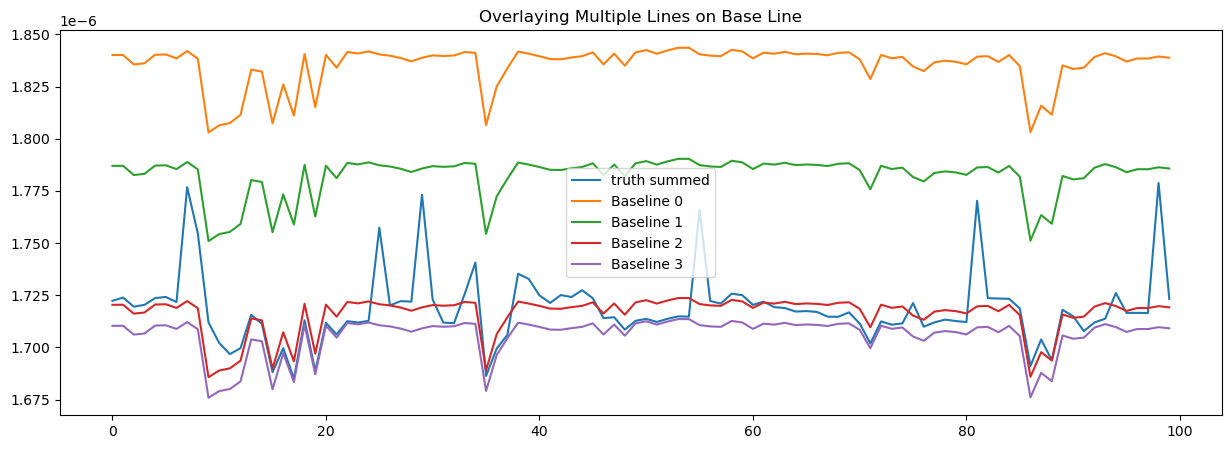

In [28]:
# Plot the base line
#plt.plot(x, y_base, label='Base line', linewidth=2, color='black')

n=1000
w=100
baseline_normalized = baseline_list/1000000000
fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths_summed[n:n+w],label = 'truth summed')
for i in range(4):
    north_approx = np.sum(baseline_normalized[:,i] * data.fp_data_full.particle_locations_n, axis=(0,1))
    south_approx = np.sum(baseline_normalized[:,i]  * data.fp_data_full.particle_locations_s, axis=(0,1))
    east_approx = np.sum(baseline_normalized[:,i]  * data.fp_data_full.particle_locations_e, axis=(0,1))
    west_approx = np.sum(baseline_normalized[:,i]  * data.fp_data_full.particle_locations_w, axis=(0,1))
    total_sum = north_approx+south_approx + east_approx + west_approx 
    mae = np.mean(np.abs(denormalized_truths_summed - total_sum ))
    print(mae)
    plt.plot(total_sum[n:n+w],label = f'Baseline {i}')


plt.legend()
plt.title("Overlaying Multiple Lines on Base Line")
print(total_sum.shape)
'''   
fig, ax = plt.subplots(1,1,figsize=(15,5))
plt.plot(denormalized_truths_summed[n:n+w],label = 'truth summed')
plt.plot(denormalized_predictions_summed[n:n+w],label = 'prediction summed')
# Loop to add different lines on top

for i in range(1, 4):  # Just 3 variations for demo
    y = np.sin(x + i * 0.5)  # Example of shifting the sine wave
    plt.plot(x, y, label=f'Line {i}')

# Add legend and show plot
plt.legend()
plt.title("Overlaying Multiple Lines on Base Line")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()
''' 


In [7]:
def apply_threshold(observed_precip, model_precip, to_correct=None, thr=0, replacement_val= 0, mult_factor=1):
    """
    Perform only the threshold step from the Local Intensity Scaling (LOCI) method.

    Parameters:
        observed_precip (numpy.ndarray): Array of observed daily precipitation values.
        model_precip (numpy.ndarray): Array of model daily precipitation values.
        to_correct - optional. Pass array of test data to be corrected with the threshold determined on the validation data

    Returns:
        - If to_correct=None, returns threshold
        - else, adjusts test data passed and returns it
    """
    wet_day_frequency_observed = mult_factor*np.sum(observed_precip > thr)
    wet_day_threshold_model = np.percentile(model_precip, 100-((100.0 * wet_day_frequency_observed) /  np.prod(np.shape(model_precip))))
    #print(wet_day_threshold_model)
    if to_correct is not None:
        corrected=np.copy(to_correct)
        corrected[corrected<=wet_day_threshold_model] = replacement_val
        return corrected
    else:
        return wet_day_threshold_model


def quantile_mapping_interp(truths, preds, to_correct, n_quantiles=100, mode="replace", thr=0, replacement_val=0, mult_factor=1, fp_noise=None):
    """
    apply quantile mapping to a test set "to_correct", based on a validation set "truths" and "preds"
    steps:
        1. apply threshold (remove background values based on validation set) 
            background values in the original space are zero, in the logspace are around -3
            thr is the value under which we consider background values
            replacement_val is the value to replace background with
        
        2. calculate the CDF of the true footprints and of the predicted footprints (on the validation set)

        3. do quantile mapping
            - find linear relationship f that does f(predicted validation CDF) = percentile
            - apply to test set f(predicted test CDF) = percentile labels
            - find linear relationship g that does g(percentile) = true validation CDF
            - apply to test percentile labels  g(percentile labels) = bias-corrected test values
        
        4. maintain all values identified as background
    
    if applying on original space, use default values
    if applying on logspace, recommended params are thr=-2, replacement_val=-3

    """

    truths = np.copy(truths)
    if fp_noise is not None:
        truths = np.where(truths<fp_noise, 0, truths)

    corrected_val = apply_threshold(truths, preds, to_correct=preds, mult_factor=mult_factor, thr=thr, replacement_val=replacement_val)
    corrected_test = apply_threshold(truths, preds, to_correct=to_correct, mult_factor=mult_factor, thr=thr, replacement_val=replacement_val)


    percentiles = np.arange(0,100.0001,100/n_quantiles)

    percentiles_observed = np.percentile(truths.flatten()[truths.flatten()>thr], percentiles)
    percentiles_simulated = np.percentile(corrected_val.flatten()[corrected_val.flatten()>thr], percentiles)
    
    corrected = np.zeros_like(to_correct)
    corrected = corrected+replacement_val
    corrected = corrected.flatten()


    preds_percentiles = np.interp(corrected_test.flatten()[corrected_test.flatten()>thr],  percentiles_simulated, percentiles)
    corresponding_truths = np.interp(preds_percentiles, percentiles, percentiles_observed)

    if mode=="replace": # this is equivalent to quantile mapping here https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/research/ukcp/ukcp18-guidance---how-to-bias-correct.pdf
        corrected[corrected_test.flatten()>thr] = corresponding_truths
    #if mode=="sum":

    #print(np.shape(to_correct))
    
    corrected = np.reshape(corrected, np.shape(to_correct))

    #print(np.shape(corrected))
    
    return corrected

### Overlapping plots for mol fraction

loading last checkpoint for num_classes-4-baselines-False-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025
loading last checkpoint for num_classes-4-baselines-False-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025
loading last checkpoint for num_classes-4-baselines-True-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025


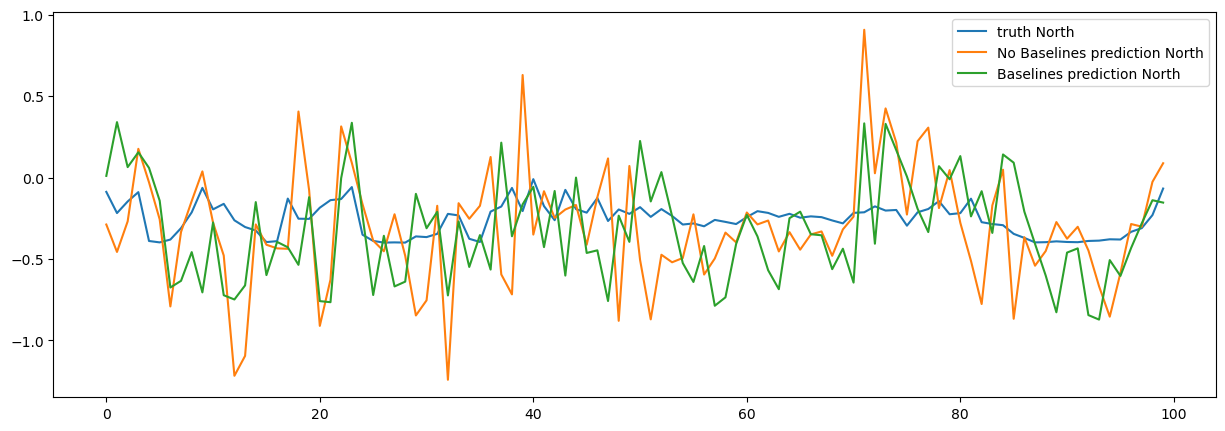

loading last checkpoint for num_classes-4-baselines-False-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025
loading last checkpoint for num_classes-4-baselines-True-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025


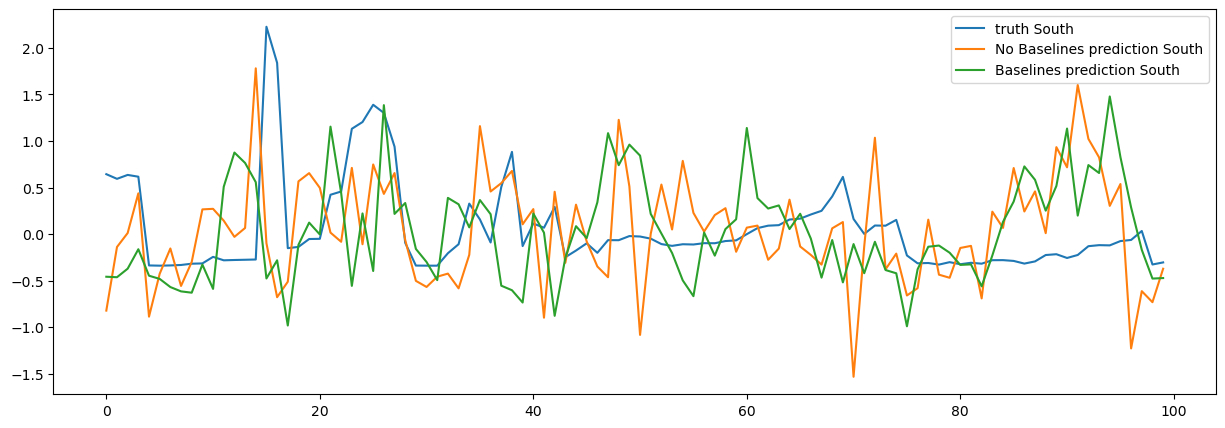

loading last checkpoint for num_classes-4-baselines-False-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025
loading last checkpoint for num_classes-4-baselines-True-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025


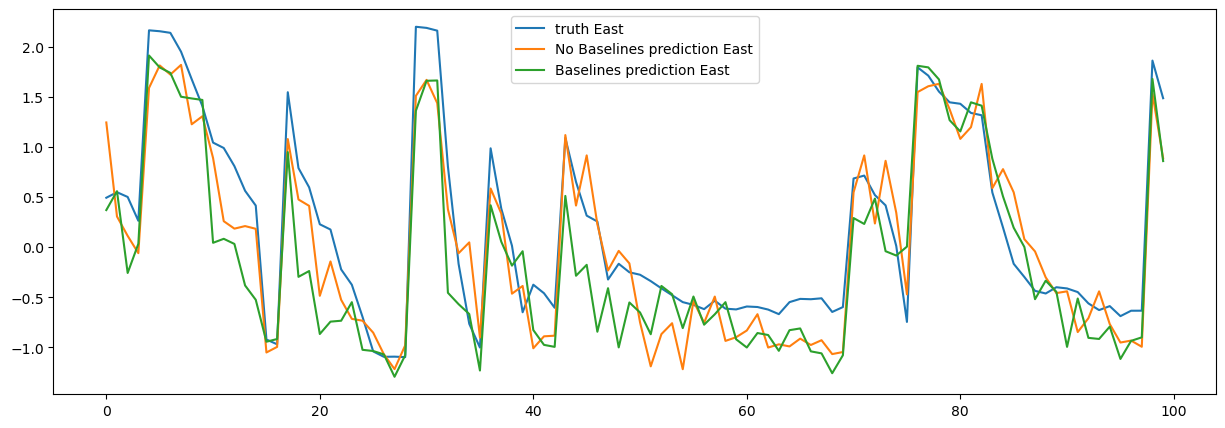

loading last checkpoint for num_classes-4-baselines-False-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025
loading last checkpoint for num_classes-4-baselines-True-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025


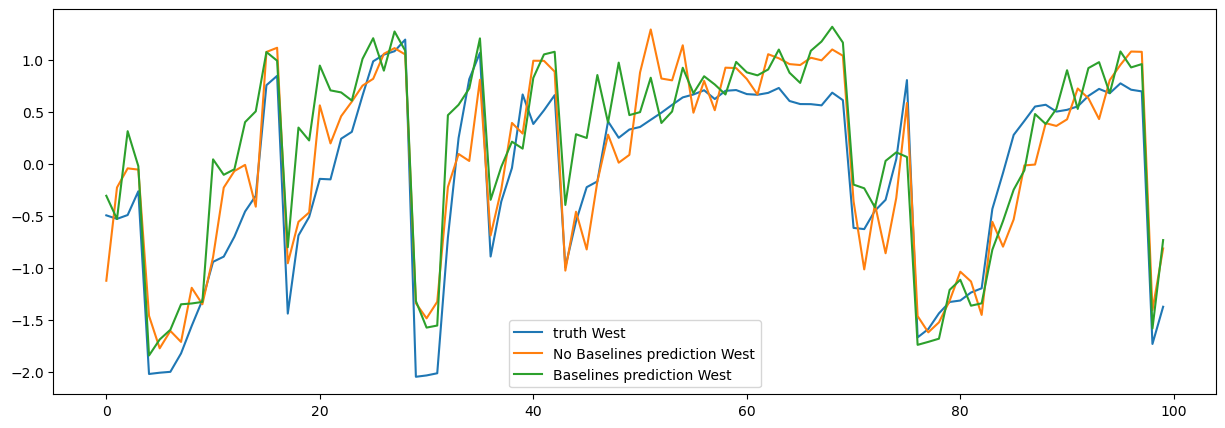

In [12]:
folder_name = 'mol_fraction_footprint'
inference_path=f"/user/work/yl18410/graphnet_LPDM_emulator/graph_weather/trained_satellite_models_fixedmet/{folder_name}/"

#model_name ='num_classes-1-baselines-False-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-10-2025'
model_names =['num_classes-4-baselines-False-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025',
              'num_classes-4-baselines-True-trainyear-2014_trainfreq-3_size-50-output_transforms-logv3_difference_transform-_epochs-150_lr-5e-05_seed-31_date-Mar-06-2025'             
              ]
label_names = ['No Baselines', 'Baselines']
direction_names = ['North', 'South', 'East','West']


data_save_name = f"{inference_path}{model_names[0]}/{model_names[0]}_final_epoch_data.pkl"



with open(f'{data_save_name}', 'rb') as f:
    loaded_filtered_data_dict = pickle.load(f)

checkpoint_to_load = get_checkpoint_to_load(model_names[0],inference_path)
checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))
output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']

truths = loaded_filtered_data_dict['test_dataset_truths']
for direction in range(truths.shape[1]):
    fig, ax = plt.subplots(1,1,figsize=(15,5))

    n =3500
    w = 100
    plt.plot(truths[n:n+w,direction],label = f'truth {direction_names[direction]}')

    for value,model_name in enumerate(model_names):
        data_save_name = f"{inference_path}{model_name}/{model_name}_final_epoch_data.pkl"
        #'trainyear-2014_trainfreq-3_baselineyears-2014-2011_normalization-all_size-50-epochs-150_baselines_False_lr-5e-05_seed-31_date-Jan-18-2025_final_epoch_data.pkl'

        #data_dict = {'test_dataset_predictions':test_out,'test_dataset_truths':test_outputs}


        with open(f'{data_save_name}', 'rb') as f:
            loaded_filtered_data_dict = pickle.load(f)


        checkpoint_to_load = get_checkpoint_to_load(model_name,inference_path)
        checkpoint = torch.load(checkpoint_to_load, map_location=torch.device('cpu'))
        output_mean, output_std = checkpoint['normalization']['outputs_mean'], checkpoint['normalization']['outputs_std']

        #truths = loaded_filtered_data_dict['test_dataset_truths']
        #normalized_truths = (truths -output_mean)/output_std
        predictions = loaded_filtered_data_dict['test_dataset_predictions']

        plt.plot(predictions[n:n+w,direction],label =f'{label_names[value]} prediction {direction_names[direction]}')
        plt.legend()
    plt.show() 

## Smoothed curves

loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-05-2025
loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-05-2025
loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-26-2025


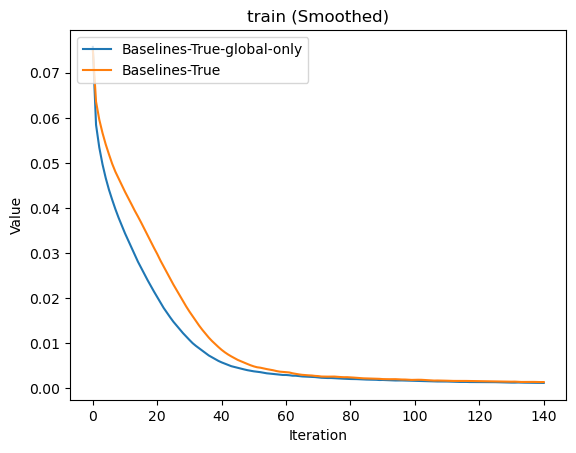

loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-05-2025
loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-26-2025


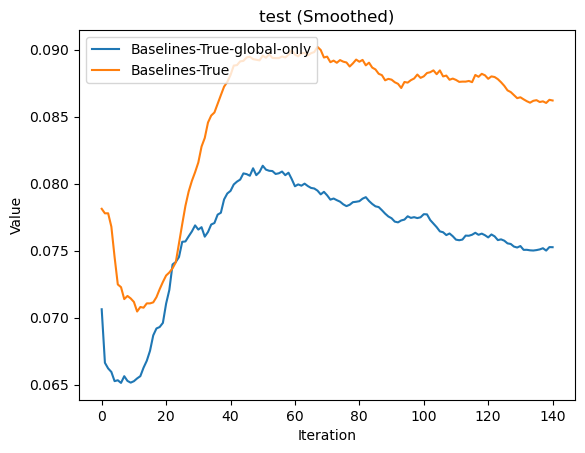

loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-05-2025
loading last checkpoint for num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-26-2025


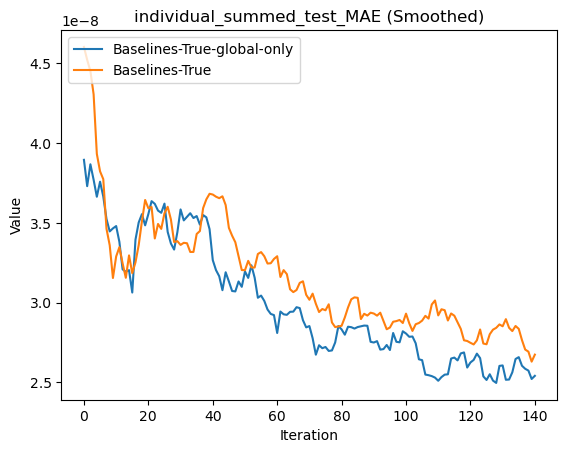

In [13]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size)/window_size, mode='valid')

directory= '/user/work/yl18410/graphnet_LPDM_emulator/graph_weather/trained_satellite_models_fixedmet/boundary_condition/'

model_names = ['num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-05-2025',
               'num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-26-2025']

label_names = ['Baselines-True-global-only','Baselines-True']

loss = get_loss(model_names[0], directory)
keys = loss.keys()

for key in keys:
    for index, model in enumerate(model_names):
        loss = get_loss(model, directory)
        smoothed = moving_average(loss[key], window_size=10)  # Apply moving average here
        plt.plot(smoothed, label=label_names[index])

    plt.xlabel('Iteration')
    plt.ylabel('Value')
    plt.title(f"{key} (Smoothed)")
    plt.legend(loc='upper left')
    plt.show()
    plt.close()

loading last checkpoint for num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-06-2025
loading last checkpoint for num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-06-2025
loading last checkpoint for num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-27-2025


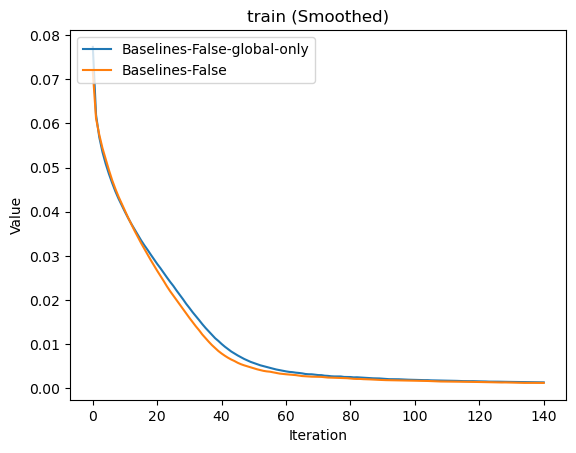

loading last checkpoint for num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-06-2025
loading last checkpoint for num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-27-2025


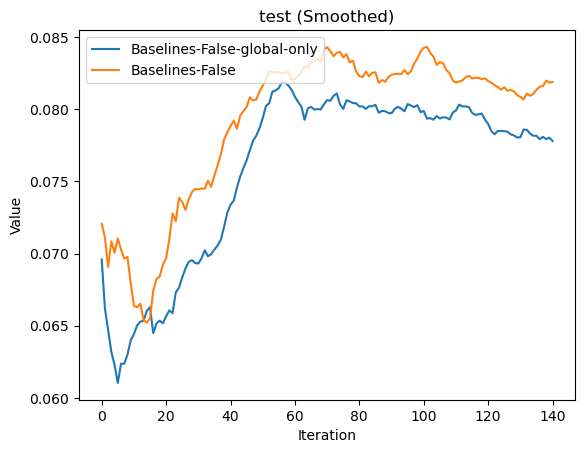

loading last checkpoint for num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-06-2025
loading last checkpoint for num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-27-2025


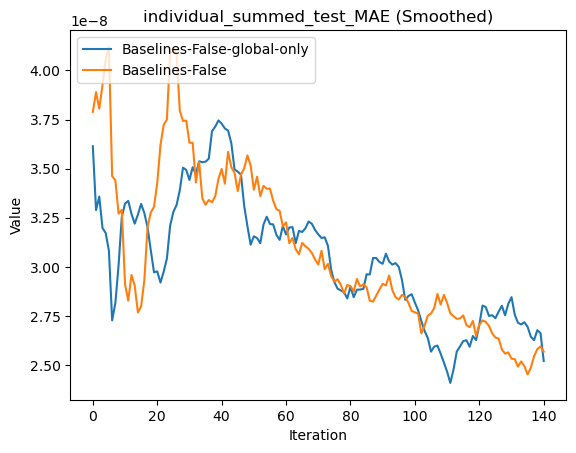

In [14]:
directory= '/user/work/yl18410/graphnet_LPDM_emulator/graph_weather/trained_satellite_models_fixedmet/boundary_condition/'

model_names = [#'num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-05-2025',
               'num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-May-06-2025',
               #'num_classes-4-baselines-True-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-26-2025'         
               'num_classes-4-baselines-False-normalization-all-trainyear-2014_trainfreq-3_size-100-_epochs-150_lr-5e-05_seed-31_date-Apr-27-2025'
               ]

label_names = ['Baselines-False-global-only','Baselines-False']

loss = get_loss(model_names[0], directory)
keys = loss.keys()

for key in keys:
    for index, model in enumerate(model_names):
        loss = get_loss(model, directory)
        smoothed = moving_average(loss[key], window_size=10)  # Apply moving average here
        plt.plot(smoothed, label=label_names[index])

    plt.xlabel('Iteration')
    plt.ylabel('Value')
    plt.title(f"{key} (Smoothed)")
    plt.legend(loc='upper left')
    plt.show()
    plt.close()